## **Trabajo Práctico 5** - Redes Neuronales Artificiales

Versión original: Estefanía De Ellia (2022)

Modificado por: Carolina Tauro y César Maglione (2024)

### **1) Preparo los datos**

Se extrajeron imágenes de pájaros y aviones de la base de datos CIFAR-10:

https://www.cs.toronto.edu/~kriz/cifar.html

Las imágenes están guardadas en el archivo "mydataset.pkl". Para esto se usó la librería pickle de Python para transformar los datos que originalmente tenían formato binario. La última celda de esta notebook tiene el código que se usó para este proceso.

El siguiente bloque de código es para leer el archivo con nuestros datos y guardarlos en un objeto de python tipo DataFrame (pandas). También hay una función show_images para graficar las imágenes, usando la libreria matplotlib.

Notar que hay **6038** imágenes, cada figura tiene _32x32_ píxeles y tienen los 3 canales RGB necesarios para poder graficarlos en color real. Además se le agregó un rótulo que las identifica: las imágenes de __pájaros__ tienen label __"0"__, y para los __aviónes__ el label es __"1"__.

Como resultado, el dataframe tiene **6038** filas (una por cada imágen) y **3073** columnas (32x32x3 + 1 para el label)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
            r0        r1        r2        r3        r4        r5        r6  \
3085  0.501961  0.423529  0.533333  0.533333  0.533333  0.537255  0.552941   
1431  0.149020  0.145098  0.149020  0.149020  0.149020  0.145098  0.145098   
4996  0.701961  0.713725  0.725490  0.733333  0.729412  0.729412  0.733333   

            r7        r8        r9  ...     b1015     b1016     b1017  \
3085  0.521569  0.380392  0.396078  ...  0.400000  0.392157  0.360784   
1431  0.145098  0.141176  0.141176  ...  0.313725  0.317647  0.333333   
4996  0.737255  0.737255  0.741176  ...  0.631373  0.627451  0.615686   

         b1018     b1019     b1020     b1021     b1022     b1023  label  
3085  0.356863  0.356863  0.360784  0.360784  0.360784  0.360784      1  
1431  0.337255  0.392157  0.588235  0.886275  0.796078  0.654902      0  
4996  0.580392  0.596078  0.611765  0.63921

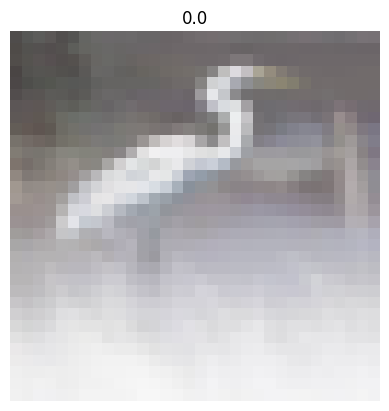

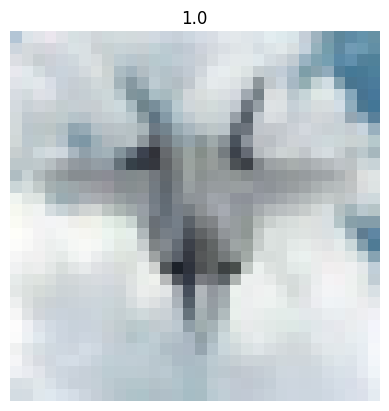

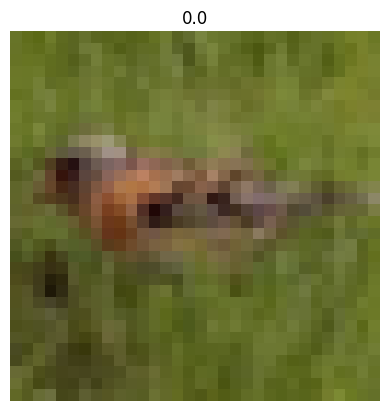

3072


In [ ]:
# Importamos las librerías que vamos a usar
# Para leer y procesar datos en masa
import numpy as np
import pandas as pd

# Para mostrar las imágenes
import matplotlib.pyplot as plt

# Para tareas generales de machine learning, medir resultados, separar conjuntos
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# Para construir y entrenar redes neuronales
from keras.models import Sequential
from keras.layers import Dense, Activation, Input, Dropout, Convolution2D, MaxPooling2D, Flatten

# Para acceder a los archivos de google drive
from google.colab import drive
drive.mount('/content/drive')

data = pd.read_pickle('/content/drive/My Drive/Docencia-Germán/CONAE/2024/Numérico2024/TPRedes/cifar-10-batches-py/mydataset.pkl')
print (data.sample(3))  # Entre () poner el numero de filas que quiero imprimir
print (data.shape)

picture_size = 32
channels = 'rgb'

input_columns = []
for color in channels:
    input_columns.extend(['%s%i' % (color, i)
            for i in range(picture_size**2)])

def show_images(samples, title=None):
	for index, sample in samples.iterrows():
		if title is not None:
			plt.title(str(sample[title]))
		sample_as_grid =  sample[input_columns].values.reshape(len(channels), picture_size, picture_size)
		sample_as_grid = np.transpose(sample_as_grid, (1,2,0))
		plt.axis('off')
		plt.imshow(sample_as_grid, interpolation='nearest')

		plt.show()

show_images(data.sample(3), title='label')  # Entre () poner la contidad de imágenes que quiero visualizar
print(len(input_columns))

### **2) Selecciono el conjunto de entrenamiento y el de testeo**

Vamos a separar el conjunto completo de imágenes en dos subconjuntos:

*   Conjunto de entrenamiento (train): se usa para generar las conexiones de la red. Es el conjunto más grande, por ejemplo se sueles usar un 80% de los datos. Pero nunca se puede usar el 100%!!!
*   Conjunto de testeo (test): se usa para validar el funcionamiento de la red generada. Para esto dejamos apartados una cantidad de datos que no han sido usados para entrenar la red (sino es trampa!). Usualmente un 20% del conjunto total.

La función `extract_inputs` sirve para extraer los datos del DataFrame y guardarlos en una estructura array de numpy (porque así lo requiere keras)

In [ ]:
# Separamos el 20% de las imágenes para testear
# train_test_split (libreria sklearn): Split arrays or matrices into random train and test subsets.
train, test = train_test_split(data, test_size=0.2)

#print (train)
sets = (
	('train', train),
	('test', test),
)

# Imprimo los labels de cada subconjunto (train y test)
# Así verifico la cantidad de pájaros y aviones que se usan en cada caso
# Notar que deben estar equilibrados.
for set_name, set_data in sets:
	print ('#' *20, set_name, 'labels', '#' *20)
	print (set_data.label.value_counts())
	print (" ")

# Transformo el dataset en un array numpy para que la librería keras pueda usarlo
def extract_inputs(dataset):
	return dataset[input_columns].values

#print(type(extract_inputs(train)))
#print(extract_inputs(train).shape)
#print(train.label.values.shape)

#################### train labels ####################
label
0    2446
1    2384
Name: count, dtype: int64
 
#################### test labels ####################
label
0    605
1    603
Name: count, dtype: int64
 


**3) Construcción de la red: definición, compilación, entrenamiento**

3.1) Definición de la red

Construimos una red tipo perceptron multi-capa usando el modelo *Sequential* de *Python* (modelo secuencial de capas). Para esto necesitamos definir la capa de entrada, las capas ocultas y la capa de salida.

* Capa de entrada: 3072 neuronas
* Capa oculta: 50 neuronas con 3072 entradas (función de activación tanh: resultado entre -1 y 1)
* Capa oculta: 50 neuronas con 50 entradas (función de activación tanh)
* Capa de salida: 1 neurona (puede tomar valor 0 o 1) (función de activación sigmoid: resultado entre 0 y 1)

Obs: Una capa de tipo Dense, significa que todas las salida de la capa anterior, son entradas de la proxima capa.

3.2) Compilar la red

* **optimizer**: es la función que va a determinar como se van a ir ajustando los pesos de la red de manera inteligente.
adam es una variante de descenso por el gradiente, la más completa dentro de lo que tiene implementado keras.
* **loss**: es la funcion de pérdida, es decir como se va a calcular el error. *'binary_crossentropy'* es una de las funciones más usadas para salidas binarias (0 y 1), es decir cuando se quiere clasificar entre dos categorías
* **metricas= 'accuracy'**, porcentajes de aciertos, es decir, cuantos de todos los ejemplos que está prediciendo son correctos.

3.3) Entrenar la red

* **epochs**: es la cantidad de iteraciones sobre el conjunto entero de datos input-output.
* **batch_size**: indica cada cuantas imágenes se ajustan los pesos.

Epoch 1/10
49/49 [==============================] - 1s 12ms/step - loss: 0.6511 - accuracy: 0.6542 - val_loss: 0.5876 - val_accuracy: 0.6962
Epoch 2/10
49/49 [==============================] - 0s 8ms/step - loss: 0.5307 - accuracy: 0.7567 - val_loss: 0.5007 - val_accuracy: 0.7699
Epoch 3/10
49/49 [==============================] - 0s 8ms/step - loss: 0.5244 - accuracy: 0.7530 - val_loss: 0.5023 - val_accuracy: 0.7856
Epoch 4/10
49/49 [==============================] - 0s 7ms/step - loss: 0.5056 - accuracy: 0.7783 - val_loss: 0.5054 - val_accuracy: 0.7790
Epoch 5/10
49/49 [==============================] - 0s 7ms/step - loss: 0.5076 - accuracy: 0.7712 - val_loss: 0.5241 - val_accuracy: 0.7550
Epoch 6/10
49/49 [==============================] - 0s 8ms/step - loss: 0.5025 - accuracy: 0.7735 - val_loss: 0.4896 - val_accuracy: 0.7707
Epoch 7/10
49/49 [==============================] - 0s 8ms/step - loss: 0.4873 - accuracy: 0.7870 - val_loss: 0.4716 - val_accuracy: 0.7906
Epoch 8/10
49/49 [=

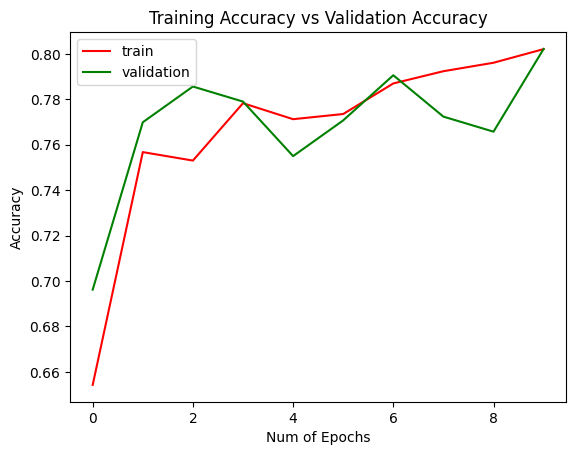

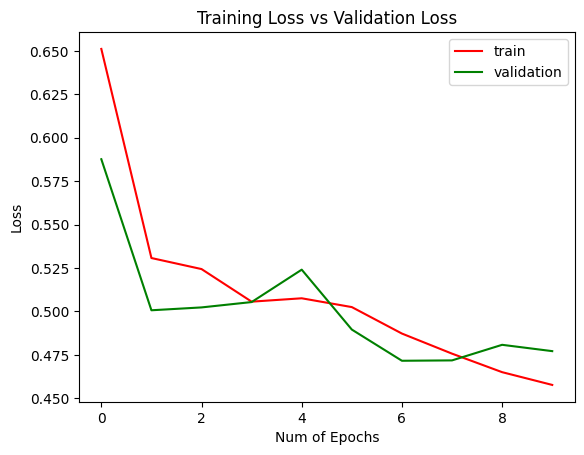

In [ ]:
# 3.1) Definir la red
model = Sequential([
  #1er capa Dense de 50 neuronas, con 3072 entradas cada neurona
	Dense(50, input_shape=(len(input_columns),)),
	Activation('tanh'),

	Dense(50),
	Activation('tanh'),

	Dense(1), #capa de salida, con una sola neurona
	Activation('sigmoid'),

])

# 3.2) Compilar la red

model.compile(
	optimizer='adam',
	loss='binary_crossentropy', #entropía cruzada binaria
	metrics = ['accuracy',],
)

# 3.3) Entrenar la red

#1er parametro son las entradas numpy array (4830, 3072)
#2do parametro salida, array numpy 1D  [1 0 0 ... 0 1 1], con dimension (4830,)
snn = model.fit(
	extract_inputs(train),
	train.label.values,
	epochs=10,
	batch_size=100,
  validation_data=(extract_inputs(test), test.label.values)
)

plt.figure(0)
plt.plot(snn.history['accuracy'],'r')
plt.plot(snn.history['val_accuracy'],'g')
plt.xlabel("Num of Epochs")
plt.ylabel("Accuracy")
plt.title("Training Accuracy vs Validation Accuracy")
plt.legend(['train','validation'])
plt.show()

plt.figure(1)
plt.plot(snn.history['loss'],'r')
plt.plot(snn.history['val_loss'],'g')
plt.xlabel("Num of Epochs")
plt.ylabel("Loss")
plt.title("Training Loss vs Validation Loss")
plt.legend(['train','validation'])
plt.show()


#Algunas pruebas
#evaluation = model.evaluate(x=extract_inputs(test), y=test.label.values, batch_size=128, verbose=1)
#print ("[loss,accuracy]")
#print (evaluation)


**4) Evaluación del desempeño de la red**

  Un informe de clasificación se utiliza para medir la calidad de las predicciones de un algoritmo de clasificación. Cuántas predicciones son Verdaderas y cuántas son Falsas. Más específicamente, los verdaderos positivos, los falsos positivos, los verdaderos negativos y los falsos negativos se utilizan para predecir las métricas de un informe de clasificación
  Las métricas se calculan utilizando verdaderos y falsos positivos, verdaderos y falsos negativos. Positivo y negativo en este caso son nombres genéricos para las clases predichas. Hay cuatro formas de comprobar si las predicciones son correctas o incorrectas:

    TN / True Negative: cuando un caso fue negativo y se predijo negativo
    TP / True Positive: cuando un caso fue positivo y se predijo positivo
    FN / Falso Negativo: cuando un caso fue positivo pero se predijo negativo
    FP / Falso Positivo: cuando un caso fue negativo pero se predijo positivo

##Precisión (Precision)
¿Qué porcentaje de sus predicciones fueron correctas?

La precisión es la capacidad de un clasificador de no etiquetar una instancia positiva que en realidad es negativa. Para cada clase se define como la relación entre los verdaderos positivos y la suma de verdaderos positivos y falsos positivos.

TP – Verdaderos Positivos

FP – Falsos Positivos

Precisión: exactitud de las predicciones positivas.

Precisión = TP/(TP + FP)

##Recordar  (Recall)
¿Qué porcentaje de los casos positivos atrapó?

La recuperación es la capacidad de un clasificador para encontrar todas las instancias positivas. Para cada clase se define como la proporción de verdaderos positivos a la suma de verdaderos positivos y falsos negativos.

FN – Falsos Negativos

Recall: Fracción de positivos que se identificaron correctamente.

Recuperar = TP/(TP+FN)

##Puntaje F1 (f1-score)
¿Qué porcentaje de predicciones positivas fueron correctas?

La puntuación F1 es una media armónica ponderada de precisión y recuperación tal que la mejor puntuación es 1,0 y la peor es 0,0. En términos generales, los puntajes de F1 son más bajos que las medidas de precisión, ya que incorporan precisión y recuperación en su cálculo. Como regla general, se debe usar el promedio ponderado de F1 para comparar modelos de clasificador, no la precisión global.

Puntuación F1 = 2*(Recordar * Precisión) / (Recordar + Precisión)



In [ ]:
# Precision: ¿qué porcentaje de sus predicciones fueron correctas? La precisión es la capacidad de un clasificador de no etiquetar una instancia positiva que
# en realidad es negativa.
# Recall: ¿Qué porcentaje de los casos positivos captó? Recordar es la capacidad de un clasificador para encontrar todas las instancias positivas.
# f1-score: ¿Qué porcentaje de predicciones positivas fueron correctas?. El puntaje F1 es una media armónica ponderada de precisión y recuerdo de tal manera que el mejor puntaje es 1.0 y el peor es 0.0
# Support: El soporte es el número de ocurrencias reales de la clase en el conjunto de datos especificado.

for set_name, set_data in sets:
	labels = set_data.label.values
	predicted_labels = np.rint(model.predict(extract_inputs(set_data))) #model.predict, devuelve el valor de lo que predice la red para el conjunto de datos pasada como parámetro


	print ('#' *25, set_name, '#' *25)
	#la funcion accuracy de sklearn, le das dos conjuntos de datos y calcula el % de aciertos
	#Puntuación de clasificación de precisión.
	#En la clasificación de etiquetas múltiples, esta función calcula la precisión del subconjunto
	print ('accuracy', accuracy_score(labels, predicted_labels))
	print(classification_report(labels, predicted_labels))




151/151 [==============================] - 0s 2ms/step
######################### train #########################
accuracy 0.7971014492753623
              precision    recall  f1-score   support

           0       0.75      0.89      0.82      2446
           1       0.86      0.70      0.77      2384

    accuracy                           0.80      4830
   macro avg       0.81      0.80      0.79      4830
weighted avg       0.81      0.80      0.80      4830

38/38 [==============================] - 0s 2ms/step
######################### test #########################
accuracy 0.8021523178807947
              precision    recall  f1-score   support

           0       0.75      0.90      0.82       605
           1       0.88      0.70      0.78       603

    accuracy                           0.80      1208
   macro avg       0.81      0.80      0.80      1208
weighted avg       0.81      0.80      0.80      1208






Veamos como son las imágenes para los casos en los que la red neuronal no predijo bien. Se toman 5 imágenes al azar.

38/38 [==============================] - 0s 2ms/step


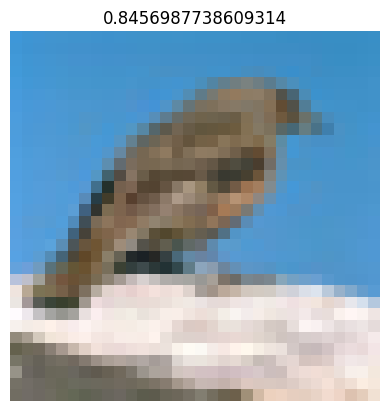

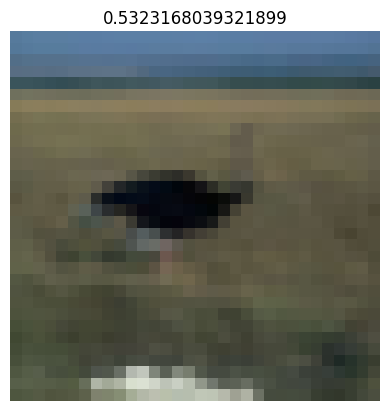

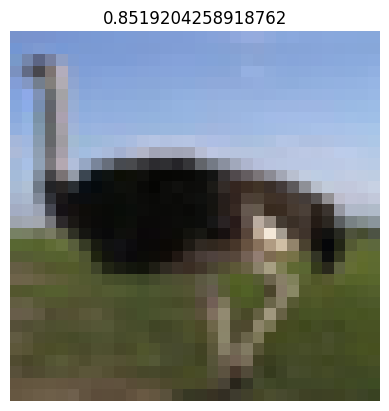

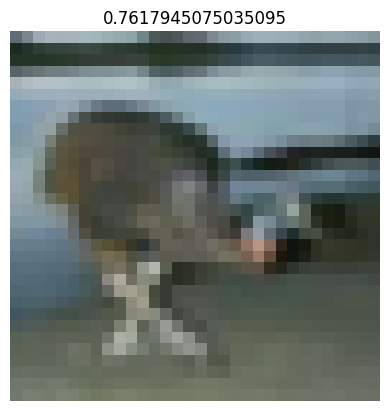

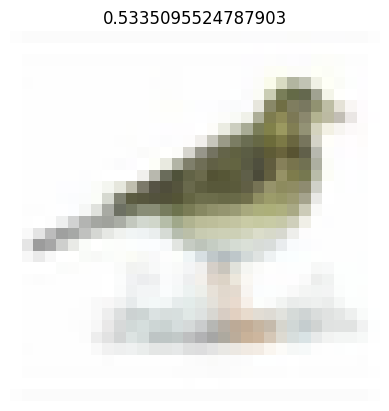

In [ ]:
test_with_predictions = test.copy()
test_with_predictions['prediction'] = model.predict(extract_inputs(test_with_predictions)) #salidas predecidas
test_with_predictions['predicted_label'] = np.rint(test_with_predictions.prediction) #las redondea
is_correct = test_with_predictions.label == test_with_predictions.predicted_label #compara reales con predecidas redondeadas

show_images(test_with_predictions[~is_correct].sample(5), title= 'prediction') #toma una muestra de 5 casos donde no predijo bien

**5) Usamos la red para clasificar una imagen nueva**

***No es un pájaro, no es un avión... es Superman!?***

El siguiente código es una función que lee imáganes cualquiera (que no estaba en el conjunto de datos usado para entrenar ni para validar la red), las redimensiona a 32x32 píxeles (para que puedan ser usadas como entradas en nuestra red neuronal) y las normaliza. Luego usa la imagen resultante como input de la red neuronal recién creada y entrenada para predicir si es pájaro o avión.

Resolvamos el dilema... Superman es más pájaro que avión o al revés?

<ipython-input-19-5efb41682370>:8: DeprecationWarning: ANTIALIAS is deprecated and will be removed in Pillow 10 (2023-07-01). Use LANCZOS or Resampling.LANCZOS instead.
  picture = picture.resize((picture_size, picture_size), Image.ANTIALIAS) #picture_size está definida mas arriba, es 32.


1/1 [==============================] - 0s 35ms/step


<ipython-input-19-5efb41682370>:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pictures_data['prediction'] = model.predict(extract_inputs(pictures_data))


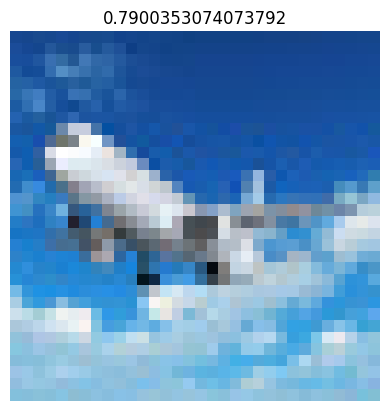

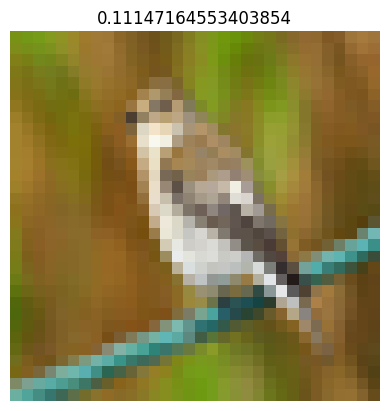

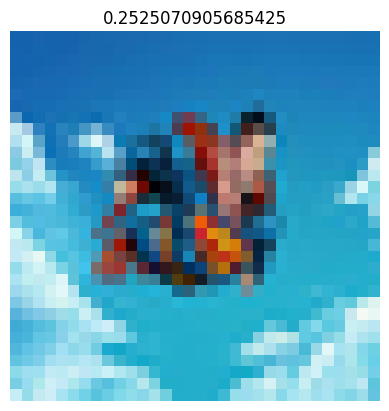

In [ ]:
from PIL import Image

def classify_pictures(pictures_paths):
    raw_pictures_data = []
    for picture_path in pictures_paths:
        picture = Image.open(picture_path)

        picture = picture.resize((picture_size, picture_size), Image.ANTIALIAS) #picture_size está definida mas arriba, es 32.
        picture_data = np.array(list(zip(*picture.getdata()))).reshape(len(input_columns))

        raw_pictures_data.append(picture_data)
    pictures_data = pd.DataFrame(raw_pictures_data, columns=input_columns)
    pictures_data[input_columns] = pictures_data[input_columns].values/255
    pictures_data['prediction'] = model.predict(extract_inputs(pictures_data))
    show_images(pictures_data, title = 'prediction')

classify_pictures([
    '/content/drive/My Drive/Docencia-Germán/CONAE/2024/Numérico2024/TPRedes/avion.jpg',
    '/content/drive/My Drive/Docencia-Germán/CONAE/2024/Numérico2024/TPRedes/pajaro.jpeg',
    '/content/drive/My Drive/Docencia-Germán/CONAE/2024/Numérico2024/TPRedes/superman.jpeg'
])



Referencias:

https://keras.io/api/

https://scikit-learn.org/stable/modules/classes.html

https://www.cs.toronto.edu/~kriz/cifar.html

https://www.apsl.net/blog/2018/02/02/tensor-flow-para-principiantes-vi-uso-de-la-api-keras/

http://yann.lecun.com/exdb/mnist/

https://enmilocalfunciona.io/deep-learning-basico-con-keras-parte-1/

https://www.youtube.com/watch?v=L2k1GUyisIo

https://hbunyamin.github.io/ml-2/Micro_and_Weighted_Macro_Averages/





El siguiente código fue utilizado para leer los archivos del set de datos CIFAR-10 y extraer solo las imágenes de pájaros o aviones (solo utilice 3 de los 6 archivos binarios incluidos en el conjunto de datos)

In [ ]:
import numpy as np
import pandas as pd
#import cPickle
import pickle
import matplotlib.pyplot as plt
#las siguientes lineas comentadas es para montar y leer los archivos desde el drive (en el caso de que estén ejecutando el código desde google colab)
from google.colab import drive
drive.mount('/content/drive')

f1 = "/content/drive/My Drive/Numerico2024/TPRedes/cifar-10-batches-py/test_batch"
f2 = "/content/drive/My Drive/Numerico2024/TPRedes/cifar-10-batches-py/data_batch_2"
f3 = "/content/drive/My Drive/Numerico2024/TPRedes/cifar-10-batches-py/data_batch_4"

#f1 = "test_batch"
#f2 = "data_batch_2"
#f3 = "data_batch_4"

def unpickle(file):
    with open(file, 'rb') as fo:
        #dict = cPickle.load(fo)
        dict = pickle.load(fo, encoding='bytes')
    return dict

matrix = []
files =[f1, f2, f3]
for f in files:
    dict = unpickle(f)
    for i in range(len(dict['labels'])):
      if (dict['labels'][i] == 0) or (dict['labels'][i] == 2):
        datos =  list(dict['data'][i]) # es una fila con 3072 datos
        datos = [d/255. for d in datos]
        lab = 1 if dict['labels'][i] == 0 else 0
        datos.append(lab)
        matrix.append(datos)


picture_size = 32
channels = 'rgb'

input_columns = []
for color in channels:
    input_columns.extend(['%s%i' % (color, i)
            for i in range(picture_size**2)])

data = {}
input_columns_with_label = input_columns[:]
input_columns_with_label.append('label')
for i in range(len(input_columns_with_label)):
  data[input_columns_with_label[i]] = [d[i] for d in matrix]

df = pd.DataFrame(data, columns = input_columns_with_label )

df.to_pickle("/content/drive/My Drive/mydataset.pkl")
#df.to_pickle("mydataset.pkl")



Mounted at /content/drive


KeyError: 'labels'